# Project part B - Financial Data (Nvidia)¨

In [1]:
import warnings

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.regression.linear_model import yule_walker
from statsmodels.tsa.stattools import acf as _acf_fn

In [3]:
import utils

In [4]:
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.dpi"] = 100

## Section 1 - Data Cleaning

In [5]:
CSV_PATH = "NVIDIA.csv"

In [6]:
raw = pd.read_csv(CSV_PATH, parse_dates=["Date"])
raw = raw.sort_values("Date").reset_index(drop=True)
raw["Close"] = pd.to_numeric(raw["Close"], errors="coerce")

close = raw.set_index("Date")["Close"].dropna()
n = len(close)

print(f"Source         : {CSV_PATH}")
print(f"Date range     : {close.index.min().date()} to {close.index.max().date()}")
print(f"Trading days n : {n}")
print(f"NaN prices     : {int(raw['Close'].isna().sum())}")
print(f"Price range    : ${close.min():.4f}  to  ${close.max():.2f}")

gap_counts = close.index.to_series().diff().dt.days.dropna().value_counts().sort_index()
print(f"\nDate gap distribution (days):\n{gap_counts.to_dict()}")

Source         : NVIDIA.csv
Date range     : 2013-12-27 to 2026-04-17
Trading days n : 3094
NaN prices     : 0
Price range    : $0.3840  to  $207.04

Date gap distribution (days):
{1.0: 2419, 2.0: 32, 3.0: 557, 4.0: 85}


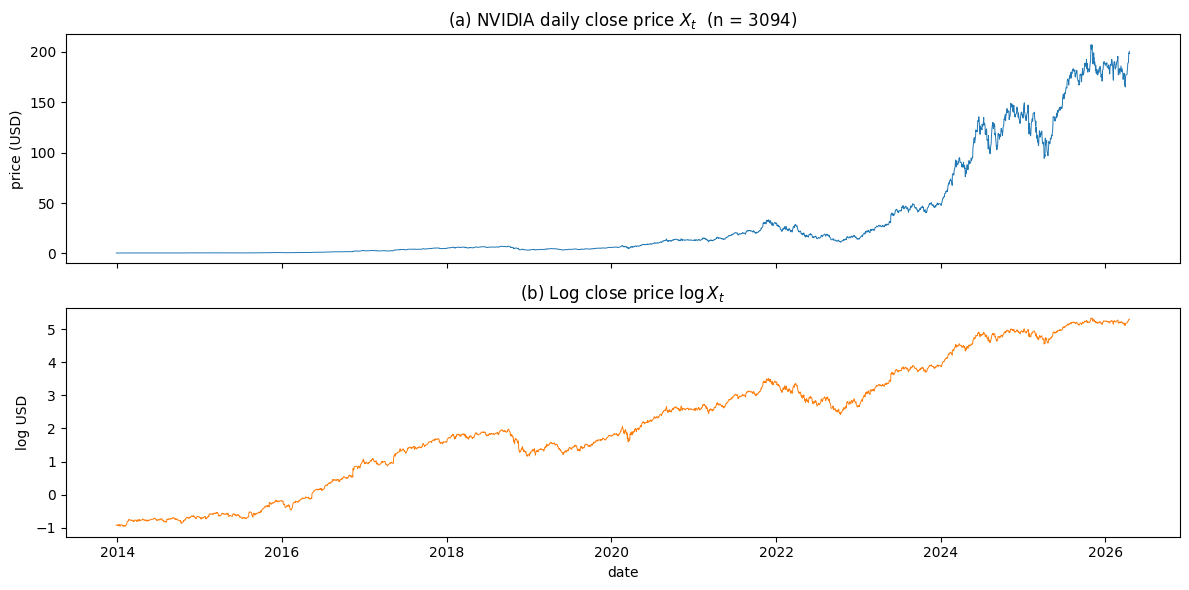

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(close.index, close.values, lw=0.7)
axes[0].set_title(f"(a) NVIDIA daily close price $X_t$  (n = {n})")
axes[0].set_ylabel("price (USD)")

log_close = np.log(close)
axes[1].plot(log_close.index, log_close.values, lw=0.7, color="C1")
axes[1].set_title(r"(b) Log close price $\log X_t$")
axes[1].set_ylabel("log USD")
axes[1].set_xlabel("date")
fig.tight_layout()
plt.show()

## Section 2 — Cleaning to stationarity

The raw series $X_t$ shows a strong upward trend and variance that grows with the level —
the price rose from $\$0.39$ in 2013 to $\$200$ in 2026 (a 500-fold increase).  We apply a
log transform (Box–Cox $\lambda = 0$) to stabilise the variance and make the multiplicative
growth additive.  We then use classical decomposition (B\&D §1.5) on $\log X_t$:

$$\log X_t \;=\; m_t + s_t^{(\text{year})} + s_t^{(\text{week})} + Y_t,$$

fitting in the order *yearly* $\to$ *weekly* $\to$ *trend*, each step on the residual of the
previous one.  Time $t$ counts trading days from the start of the series.


In [ ]:
# Yearly seasonality — harmonic regression, period d=252 trading days, k=1
D_YEAR, K_YEAR = 252, 1

s_year_vals, year_coefs = utils.fit_harmonic(log_close.values, D_YEAR, K_YEAR)
s_year = pd.Series(s_year_vals, index=log_close.index, name="yearly_seasonal")

print(f"Yearly harmonic (d={D_YEAR}, k={K_YEAR}):")
for name, val in year_coefs.items():
    print(f"  {name} = {val:+.5f}")

log_deseason_year = log_close # yearly seasonality not significant (otherwise minus s_year)


Yearly harmonic (d=252, k=1):
  a1 = +0.06599
  b1 = -0.08806


In [ ]:
# Weekly seasonality — period d=5 trading days, k=2 (saturated Fourier basis)
D_WEEK, K_WEEK = 5, 2

s_week_vals, week_coefs = utils.fit_harmonic(log_deseason_year.values, D_WEEK, K_WEEK)
s_week = pd.Series(s_week_vals, index=log_close.index, name="weekly_seasonal")

print(f"Weekly harmonic (d={D_WEEK}, k={K_WEEK}):")
for name, val in week_coefs.items():
    print(f"  {name} = {val:+.5f}")

log_deseason = log_deseason_year # weekly seasonality not significant (otherwise minus s_week)


Weekly harmonic (d=5, k=2):
  a1 = -0.00214
  b1 = -0.00080
  a2 = -0.00017
  b2 = +0.00010


In [ ]:
# # Polynomial trend — start linear, promote to quadratic if residuals show curvature
# lin_fit, lin_coefs = utils.fit_poly_trend(log_deseason.values, degree=1)
# lin_resid = log_deseason.values - lin_fit
# thirds = np.array_split(lin_resid, 3)
# third_means = [float(np.mean(x)) for x in thirds]
# third_std = float(np.std(lin_resid))
# use_quadratic = max(abs(m) for m in third_means) > 0.10 * third_std

# print(f"Linear residual thirds: {[round(m, 5) for m in third_means]}")
# print(f"Residual std          : {third_std:.5f}")
# print(f"Promote to quadratic  : {use_quadratic}")

# if use_quadratic:
#     trend_fit, trend_coefs = utils.fit_poly_trend(log_deseason.values, degree=2)
#     trend_degree = 2
# else:
#     trend_fit, trend_coefs = lin_fit, lin_coefs
#     trend_degree = 1

# print(f"\nTrend degree chosen : {trend_degree}")
# print(f"Trend coefficients  : {trend_coefs}")

# trend = pd.Series(trend_fit, index=log_close.index, name="trend")
# residuals = (log_deseason - trend).rename("residual")


Linear residual thirds: [0.04478, 0.02597, -0.07079]
Residual std          : 0.36145
Promote to quadratic  : True

Trend degree chosen : 2
Trend coefficients  : {'beta0': -0.9795985356992416, 'beta1': 0.001969263646485015, 'beta2': 1.8821093272867323e-08}


### Polynomial trend doesn't work too well

$Y_t = \nabla \log X_t = \log X_t - \log X_{t-1}$ define Y_t as difference between log returns of current time step and time step prior.

Log return range: -0.2077 to 0.2609
Mean            : 0.002015
Std             : 0.029356


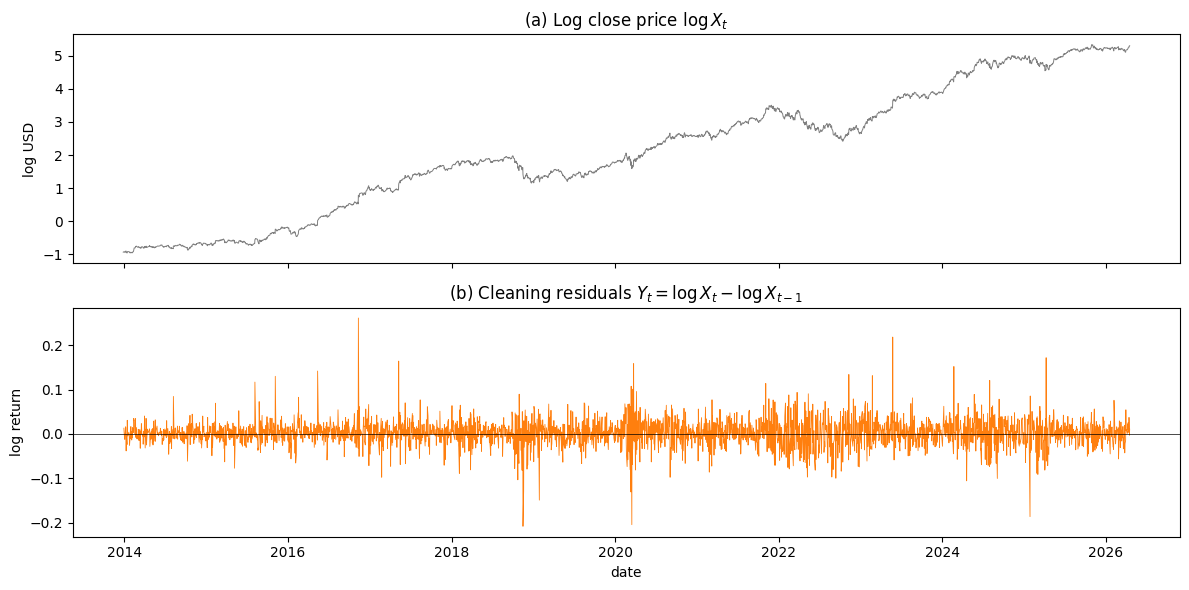

In [62]:
# First difference of log prices (log returns)
# This removes the trend without assuming a polynomial shape
residuals = log_close.diff().dropna().rename("residual")
n = len(residuals)

print(f"Log return range: {residuals.min():.4f} to {residuals.max():.4f}")
print(f"Mean            : {residuals.mean():.6f}")
print(f"Std             : {residuals.std():.6f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(log_close.index, log_close.values, lw=0.7, color="grey")
axes[0].set_title(r"(a) Log close price $\log X_t$")
axes[0].set_ylabel("log USD")

axes[1].plot(residuals.index, residuals.values, lw=0.6, color="C1")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_title(r"(b) Cleaning residuals $Y_t = \log X_t - \log X_{t-1}$")
axes[1].set_ylabel("log return")
axes[1].set_xlabel("date")

fig.tight_layout()
plt.show()



In [63]:
# # Decomposition summary plot
# fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# axes[0].plot(log_close.index, log_close.values, lw=0.7, color="grey", label=r"$\log X_t$")
# det = trend  + s_year + s_week
# axes[0].plot(det.index, det.values, lw=1.5, color="C3",
#              label=r"$\hat m_t + \hat s^{(\rm year)}_t + \hat s^{(\rm week)}_t$")
# axes[0].set_title("(a) Log close with fitted deterministic component")
# axes[0].set_ylabel("log USD")
# axes[0].legend(fontsize=8)

# axes[1].plot(s_year.index, s_year.values, lw=0.8, color="C0")
# axes[1].set_title("(b) Yearly seasonal component")
# axes[1].set_ylabel("log USD")

# axes[2].plot(s_week.index, s_week.values, lw=0.8, color="C2")
# axes[2].set_title("(c) Weekly seasonal component")
# axes[2].set_ylabel("log USD")

# axes[3].plot(residuals.index, residuals.values, lw=0.5, color="C1")
# axes[3].axhline(0, color="k", lw=0.5)
# axes[3].set_title(r"(d) Cleaning residuals $\hat Y_t$")
# axes[3].set_ylabel("residual")
# axes[3].set_xlabel("date")

# fig.tight_layout()
# plt.show()


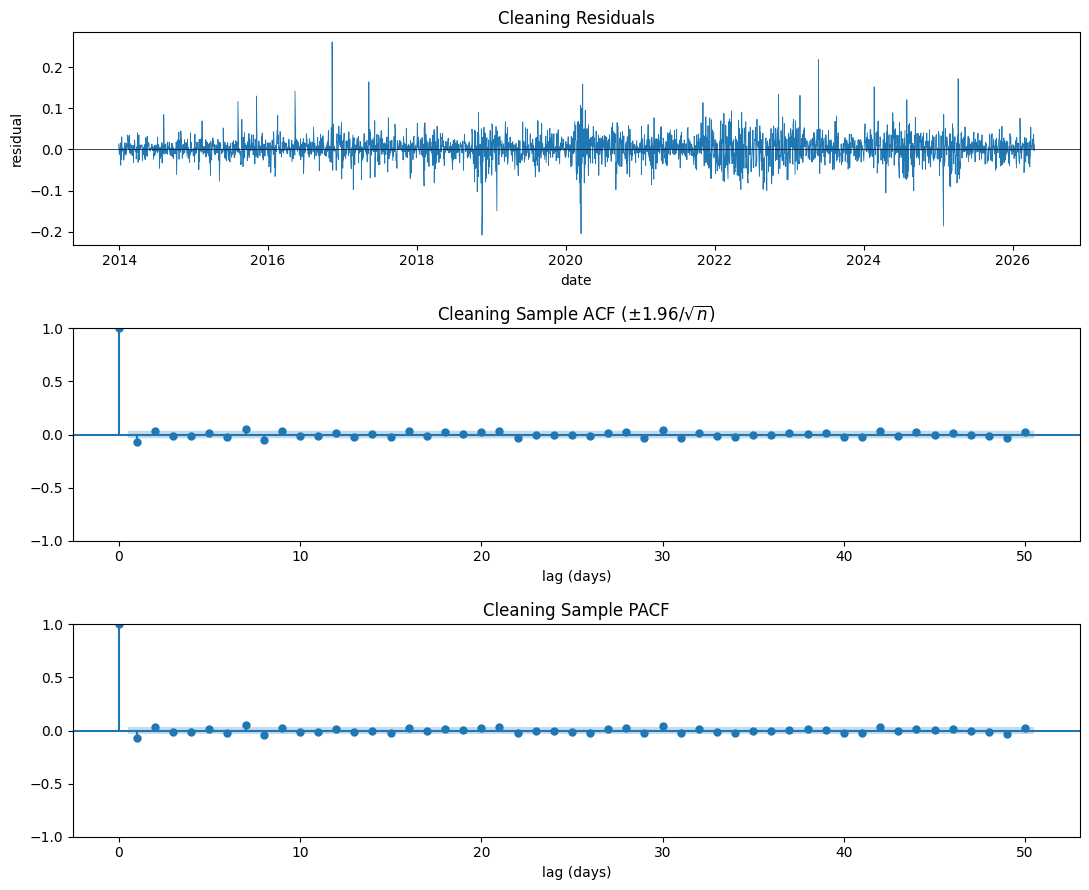

Ljung–Box on cleaning residuals (iid null, expected to reject):
    lb_stat  lb_pvalue
20  52.7622     0.0001
40  81.6596     0.0001

ACF bound   ±0.0352
ACF(1)  = -0.0702
ACF(5)  = +0.0113  (weekly lag check)
ACF(252)= +0.0231  (yearly lag check)


In [66]:
# Residual diagnostics
fig = utils.diagnostic_plots(residuals, max_lag=50, title_prefix="Cleaning ")
plt.show()

lb_clean = utils.ljung_box(residuals.values, lags=(20, 40), model_df=0)
print("Ljung–Box on cleaning residuals (iid null, expected to reject):")
print(lb_clean)

acf_vals = _acf_fn(residuals.values, nlags=50, fft=True)
bound = 1.96 / np.sqrt(n)
print(f"\nACF bound   ±{bound:.4f}")
print(f"ACF(1)  = {acf_vals[1]:+.4f}")
print(f"ACF(5)  = {acf_vals[5]:+.4f}  (weekly lag check)")
print(f"ACF(252)= {acf_vals[min(252, len(acf_vals)-1)]:+.4f}  (yearly lag check)")


## Section 2 - Fit ARMA models

In [69]:
from statsmodels.tsa.arima.model import ARIMA

MAX_P, MAX_Q = 5, 5

results = []

for p in range(MAX_P + 1):
    for q in range(MAX_Q + 1):
        if p == 0 and q == 0:
            continue
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res = ARIMA(residuals, order=(p, 0, q), trend="c").fit()
            k = p + q + 2
            aicc = utils.aicc_from_aic(res.aic, k, len(residuals))
            ar_roots = res.arroots if p > 0 else np.array([])
            ma_roots = res.maroots if q > 0 else np.array([])
            causal     = bool(np.all(np.abs(ar_roots) > 1)) if len(ar_roots) else True
            invertible = bool(np.all(np.abs(ma_roots) > 1)) if len(ma_roots) else True
            results.append({
                "model": f"ARMA({p},{q})", "p": p, "q": q,
                "AICC": aicc, "causal": causal, "invertible": invertible
            })
        except Exception:
            pass

tbl = pd.DataFrame(results).sort_values("AICC").reset_index(drop=True)
print(tbl.to_string(index=False))


    model  p  q        AICC  causal  invertible
ARMA(5,4)  5  4 -13066.1645    True        True
ARMA(4,4)  4  4 -13064.3436    True        True
ARMA(2,5)  2  5 -13064.1494    True        True
ARMA(2,0)  2  0 -13059.6741    True        True
ARMA(0,2)  0  2 -13059.3199    True        True
ARMA(1,1)  1  1 -13058.9163    True        True
ARMA(1,0)  1  0 -13058.5382    True        True
ARMA(0,3)  0  3 -13058.3360    True        True
ARMA(3,0)  3  0 -13058.0974    True        True
ARMA(1,2)  1  2 -13057.8314    True        True
ARMA(3,5)  3  5 -13057.6543    True        True
ARMA(0,1)  0  1 -13057.5759    True        True
ARMA(2,1)  2  1 -13057.3957    True        True
ARMA(1,5)  1  5 -13057.1867    True        True
ARMA(4,0)  4  0 -13056.6457    True        True
ARMA(0,4)  0  4 -13056.5122    True        True
ARMA(1,3)  1  3 -13056.3283    True        True
ARMA(1,4)  1  4 -13056.2111    True        True
ARMA(3,1)  3  1 -13056.1202    True        True
ARMA(2,2)  2  2 -13056.0184    True     

In [71]:
def fit_candidate(p, q, y_series):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = ARIMA(y_series, order=(p, 0, q), trend="c").fit()
    n_obs = int(res.nobs)
    k_params = p + q + 2
    aicc = utils.aicc_from_aic(res.aic, k_params, n_obs)
    ar_roots = res.arroots if p > 0 else np.array([])
    ma_roots = res.maroots if q > 0 else np.array([])
    causal     = (p == 0) or bool(np.all(np.abs(ar_roots) > 1))
    invertible = (q == 0) or bool(np.all(np.abs(ma_roots) > 1))
    param_names = list(res.param_names)
    param_vals  = np.asarray(res.params, dtype=float)
    bse_vals    = np.asarray(res.bse, dtype=float)
    params_dict = dict(zip(param_names, param_vals))
    return {
        "p": p, "q": q, "result": res,
        "aic": float(res.aic), "aicc": aicc,
        "sigma2": float(params_dict["sigma2"]),
        "causal": causal, "invertible": invertible,
        "ar_roots": ar_roots, "ma_roots": ma_roots,
        "param_names": param_names,
        "param_vals": param_vals,
        "bse_vals": bse_vals,
        "params_dict": params_dict,
    }


In [72]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the three candidate models
chosen_candidates = [(2, 0), (0, 2), (1, 1)]
chosen_fits = [fit_candidate(p, q, residuals) for p, q in chosen_candidates]

for f in chosen_fits:
    print("=" * 60)
    print(f"ARMA({f['p']},{f['q']})  —  Gaussian MLE via innovations algorithm")
    print(f"  AICC     = {f['aicc']:.4f}")
    print(f"  sigma²   = {f['sigma2']:.6f}")
    print(f"  causal     : {f['causal']}   (AR roots: {np.round(f['ar_roots'], 3).tolist()})")
    print(f"  invertible : {f['invertible']} (MA roots: {np.round(f['ma_roots'], 3).tolist()})")
    for name, val, se in zip(f["param_names"], f["param_vals"], f["bse_vals"]):
        print(f"    {name:>10} = {val:+.5f}  (se={se:.5f})")


ARMA(2,0)  —  Gaussian MLE via innovations algorithm
  AICC     = -13059.6741
  sigma²   = 0.000856
  causal     : True   (AR roots: [-4.636, 6.768])
  invertible : True (MA roots: [])
         const = +0.00201  (se=0.00052)
         ar.L1 = -0.06795  (se=0.01271)
         ar.L2 = +0.03187  (se=0.01448)
        sigma2 = +0.00086  (se=0.00001)
ARMA(0,2)  —  Gaussian MLE via innovations algorithm
  AICC     = -13059.3199
  sigma²   = 0.000856
  causal     : True   (AR roots: [])
  invertible : True (MA roots: [(0.936-5.177j), (0.936+5.177j)])
         const = +0.00201  (se=0.00053)
         ma.L1 = -0.06766  (se=0.01270)
         ma.L2 = +0.03613  (se=0.01418)
        sigma2 = +0.00086  (se=0.00001)
ARMA(1,1)  —  Gaussian MLE via innovations algorithm
  AICC     = -13058.9163
  sigma²   = 0.000856
  causal     : True   (AR roots: [-1.967])
  invertible : True (MA roots: [-2.269])
         const = +0.00201  (se=0.00051)
         ar.L1 = -0.50827  (se=0.13900)
         ma.L1 = +0.44071  (s

### Yule-Walker cross-check for Arma(2,0)

In [73]:
from statsmodels.regression.linear_model import yule_walker

yw_phi, yw_sigma = yule_walker(residuals.values, order=2)

best_ar = fit_candidate(2, 0, residuals)

print("Yule–Walker vs MLE, AR(2):")
for i, ph in enumerate(yw_phi, 1):
    mle_ph = float(best_ar["params_dict"].get(f"ar.L{i}", np.nan))
    print(f"  phi_{i}:  YW = {ph:+.5f}    MLE = {mle_ph:+.5f}")
print(f"  sigma²:  YW = {yw_sigma**2:.6f}    MLE = {best_ar['sigma2']:.6f}")


Yule–Walker vs MLE, AR(2):
  phi_1:  YW = -0.06796    MLE = -0.06795
  phi_2:  YW = +0.03189    MLE = +0.03187
  sigma²:  YW = 0.000856    MLE = 0.000856


### Residual Diagnostics on the ARMA residuals

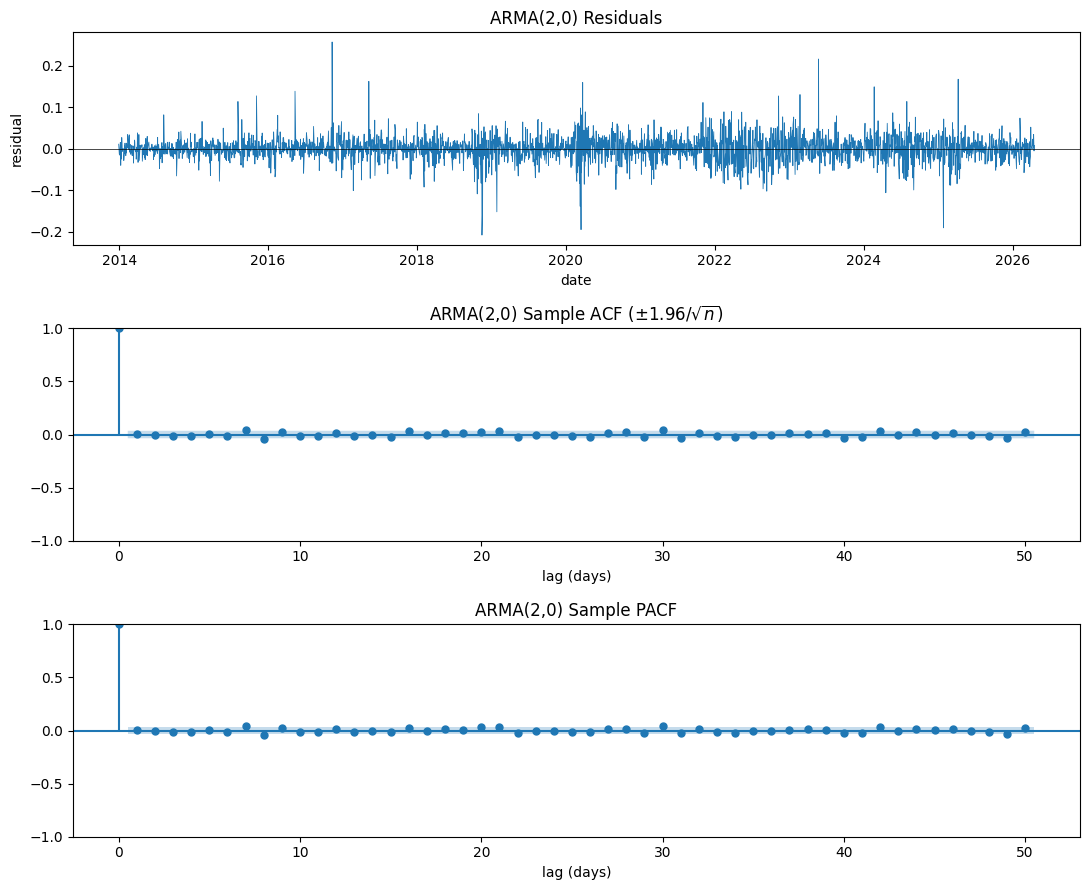

Ljung–Box on ARMA(2,0) residuals (model_df=2):
    lb_stat  lb_pvalue
20  26.8437     0.0820

p ≥ 0.05 → residuals consistent with white noise.


In [74]:
chosen = fit_candidate(2, 0, residuals)
arma_resid = pd.Series(chosen["result"].resid, index=residuals.index, name="arma_resid")

fig = utils.diagnostic_plots(arma_resid, max_lag=50, title_prefix="ARMA(2,0) ")
plt.show()

lb_arma = utils.ljung_box(arma_resid.values, lags=(20,), model_df=2)
print("Ljung–Box on ARMA(2,0) residuals (model_df=2):")
print(lb_arma)

if float(lb_arma["lb_pvalue"].iloc[0]) < 0.05:
    print("\np < 0.05 → residuals still show correlation.")
else:
    print("\np ≥ 0.05 → residuals consistent with white noise.")


## Section 3 - Forecasting

### Refit and Forecast

In [92]:
H = 30

log_close_train = log_close.iloc[:-H]
log_close_test  = log_close.iloc[-H:]
actual_price    = close.iloc[-H:].values

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    refit = ARIMA(log_close_train.values, order=(2, 1, 0), trend="t").fit()

print(f"Refit ARIMA(2,1,0) on training log prices (n_train={len(log_close_train)})")
print(refit.summary().tables[1])

fc         = refit.get_forecast(steps=H)
fc_log     = np.asarray(fc.predicted_mean)
fc_ci_log  = np.asarray(fc.conf_int(alpha=0.05))

fc_price       = np.exp(fc_log)
fc_price_lower = np.exp(fc_ci_log[:, 0])
fc_price_upper = np.exp(fc_ci_log[:, 1])


Refit ARIMA(2,1,0) on training log prices (n_train=3064)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0020      0.001      3.794      0.000       0.001       0.003
ar.L1         -0.0683      0.013     -5.347      0.000      -0.093      -0.043
ar.L2          0.0319      0.015      2.188      0.029       0.003       0.060
sigma2         0.0009   1.03e-05     83.520      0.000       0.001       0.001



### Metrics

In [93]:
rmse     = float(np.sqrt(np.mean((fc_price - actual_price) ** 2)))
mae      = float(np.mean(np.abs(fc_price - actual_price)))
coverage = float(np.mean((actual_price >= fc_price_lower) & (actual_price <= fc_price_upper)))
train_std = float(close.iloc[:-H].std())

print(f"RMSE             : {rmse:.2f} USD")
print(f"MAE              : {mae:.2f} USD")
print(f"Coverage (95%)   : {coverage:.2f}")
print(f"Training std     : {train_std:.2f} USD  (scale reference)")
print(f"RMSE / std       : {rmse / train_std:.3f}")


RMSE             : 10.90 USD
MAE              : 8.94 USD
Coverage (95%)   : 1.00
Training std     : 51.58 USD  (scale reference)
RMSE / std       : 0.211


### Forecast plot

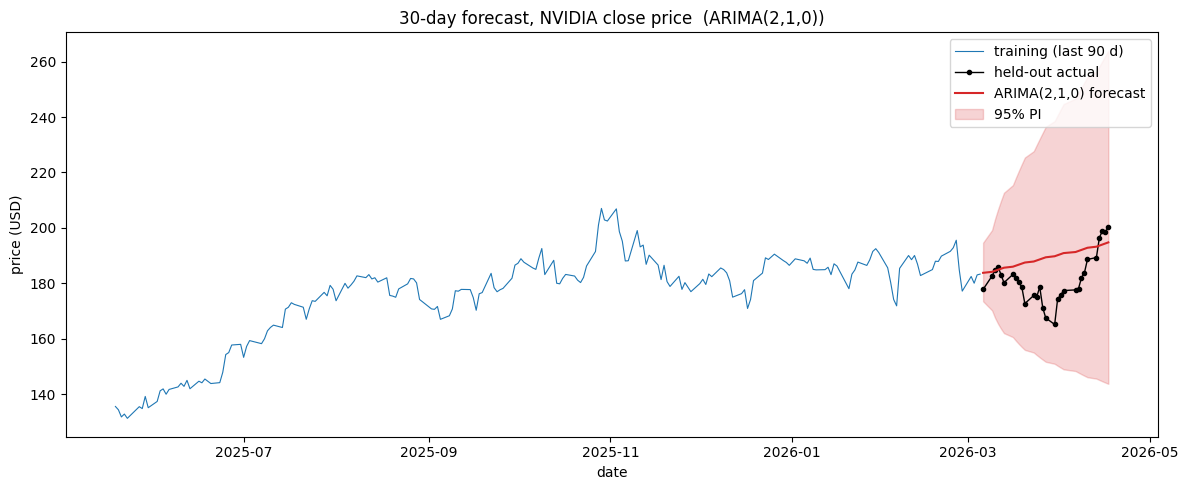

In [94]:
last_90 = close.iloc[-H-200:-H] #-H - 90

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(last_90.index, last_90.values, lw=0.8, label="training (last 90 d)")
ax.plot(log_close_test.index, actual_price, lw=1.0, color="k",
        marker="o", markersize=3, label="held-out actual")
ax.plot(log_close_test.index, fc_price, lw=1.5, color="C3",
        label="ARIMA(2,1,0) forecast")
ax.fill_between(log_close_test.index, fc_price_lower, fc_price_upper,
                color="C3", alpha=0.2, label="95% PI")
ax.set_title("30-day forecast, NVIDIA close price  (ARIMA(2,1,0))")
ax.set_xlabel("date")
ax.set_ylabel("price (USD)")
ax.legend()
fig.tight_layout()
plt.show()


## Second plot (H=252)

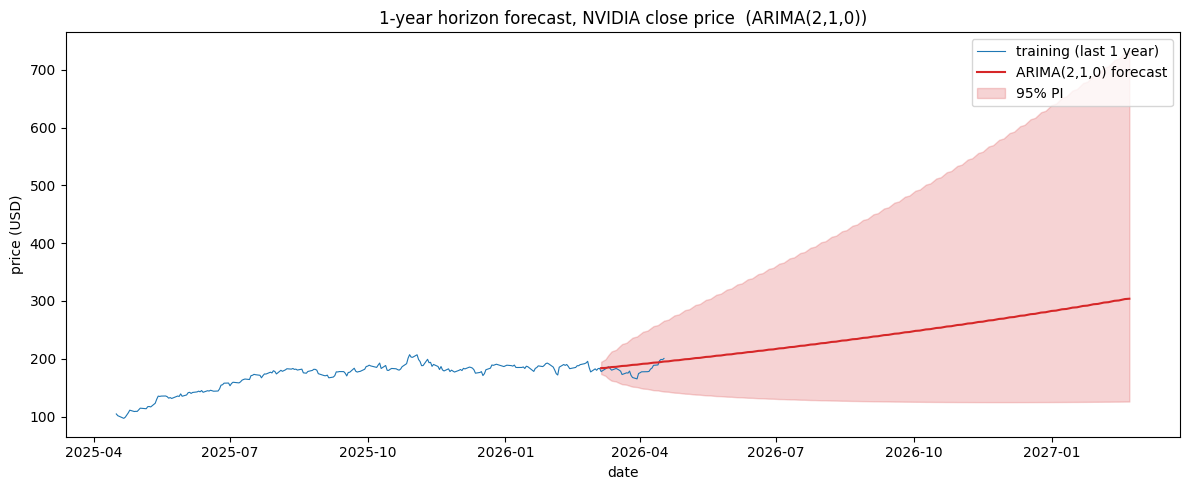

PI width at h=1  : 21.14 USD
PI width at h=30 : 120.20 USD
PI width at h=252: 606.93 USD


In [95]:
H_long = 252  # 1-year horizon for illustration

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    refit_long = ARIMA(log_close_train.values, order=(2, 1, 0), trend="t").fit()

fc_long        = refit_long.get_forecast(steps=H_long)
fc_log_long    = np.asarray(fc_long.predicted_mean)
fc_ci_log_long = np.asarray(fc_long.conf_int(alpha=0.05))

fc_price_long       = np.exp(fc_log_long)
fc_price_long_lower = np.exp(fc_ci_log_long[:, 0])
fc_price_long_upper = np.exp(fc_ci_log_long[:, 1])

# Use actual dates if available, otherwise generate trading-day index
last_train_date = log_close_train.index[-1]
future_dates = close.iloc[-H_long:].index if H_long <= len(close) - len(log_close_train) else pd.date_range(last_train_date, periods=H_long + 1, freq="B")[1:]

prior_data = close.iloc[-len(log_close_train):][-252:]  # last year of training

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prior_data.index, prior_data.values, lw=0.8, label="training (last 1 year)")
ax.plot(future_dates, fc_price_long, lw=1.5, color="C3", label="ARIMA(2,1,0) forecast")
ax.fill_between(future_dates, fc_price_long_lower, fc_price_long_upper,
                color="C3", alpha=0.2, label="95% PI")
ax.set_title("1-year horizon forecast, NVIDIA close price  (ARIMA(2,1,0))")
ax.set_xlabel("date")
ax.set_ylabel("price (USD)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"PI width at h=1  : {fc_price_long_upper[0]  - fc_price_long_lower[0]:.2f} USD")
print(f"PI width at h=30 : {fc_price_long_upper[29] - fc_price_long_lower[29]:.2f} USD")
print(f"PI width at h=252: {fc_price_long_upper[-1]  - fc_price_long_lower[-1]:.2f} USD")


## Benchmarking with simple ARMA(1,0)

In [97]:
# Random walk benchmark

# Fit random walk (drift only, no AR terms)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    refit_rw = ARIMA(log_close_train.values, order=(0, 1, 0), trend="t").fit()

fc_rw        = refit_rw.get_forecast(steps=H)
fc_log_rw    = np.asarray(fc_rw.predicted_mean)
fc_ci_log_rw = np.asarray(fc_rw.conf_int(alpha=0.05))

fc_price_rw       = np.exp(fc_log_rw)
fc_price_rw_lower = np.exp(fc_ci_log_rw[:, 0])
fc_price_rw_upper = np.exp(fc_ci_log_rw[:, 1])

rmse_rw     = float(np.sqrt(np.mean((fc_price_rw - actual_price) ** 2)))
mae_rw      = float(np.mean(np.abs(fc_price_rw - actual_price)))
coverage_rw = float(np.mean((actual_price >= fc_price_rw_lower) & (actual_price <= fc_price_rw_upper)))

print(f"\n{'Model':<20} {'RMSE':>8} {'MAE':>8} {'Coverage':>10}")
print("-" * 48)
print(f"{'ARIMA(2,1,0)':<20} {rmse:>8.2f} {mae:>8.2f} {coverage:>10.2f}")
print(f"{'Random walk':<20} {rmse_rw:>8.2f} {mae_rw:>8.2f} {coverage_rw:>10.2f}")



Model                    RMSE      MAE   Coverage
------------------------------------------------
ARIMA(2,1,0)            10.90     8.94       1.00
Random walk             10.83     8.89       1.00


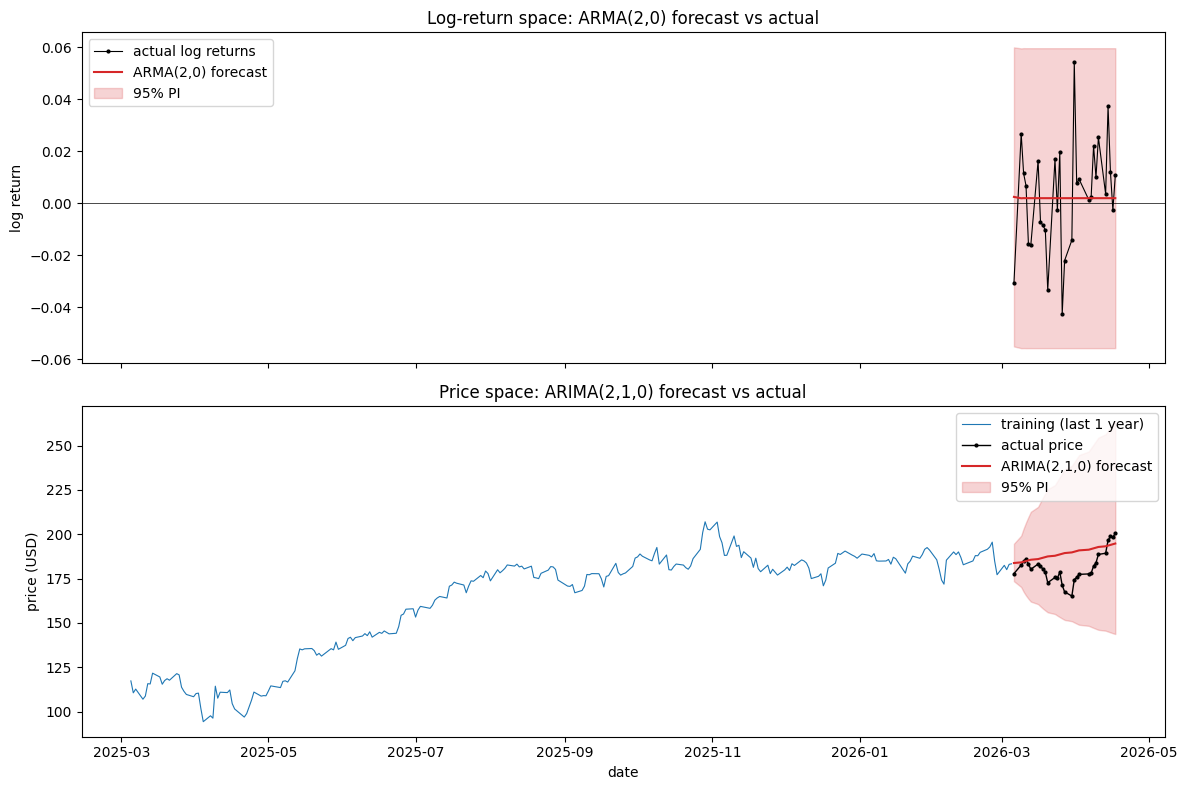

In [98]:
# Log-return space forecast

# Forecast in log-return space using the ARMA(2,0) fit on residuals
train_resid = residuals.iloc[:-H]
test_resid  = residuals.iloc[-H:]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    refit_ret = ARIMA(train_resid.values, order=(2, 0, 0), trend="c").fit()

fc_ret    = refit_ret.get_forecast(steps=H)
fc_mean_r = np.asarray(fc_ret.predicted_mean)
fc_ci_r   = np.asarray(fc_ret.conf_int(alpha=0.05))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top panel — log return space
axes[0].plot(test_resid.index, test_resid.values, lw=0.8, color="k",
             marker="o", markersize=2, label="actual log returns")
axes[0].plot(test_resid.index, fc_mean_r, lw=1.5, color="C3",
             label="ARMA(2,0) forecast")
axes[0].fill_between(test_resid.index, fc_ci_r[:, 0], fc_ci_r[:, 1],
                     color="C3", alpha=0.2, label="95% PI")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_title("Log-return space: ARMA(2,0) forecast vs actual")
axes[0].set_ylabel("log return")
axes[0].legend()

# Bottom panel — price space
prior = close.iloc[-H - 252:-H]
axes[1].plot(prior.index, prior.values, lw=0.8, color="C0",
             label="training (last 1 year)")
axes[1].plot(log_close_test.index, actual_price, lw=1.0, color="k",
             marker="o", markersize=2, label="actual price")
axes[1].plot(log_close_test.index, fc_price, lw=1.5, color="C3",
             label="ARIMA(2,1,0) forecast")
axes[1].fill_between(log_close_test.index, fc_price_lower, fc_price_upper,
                     color="C3", alpha=0.2, label="95% PI")
axes[1].set_title("Price space: ARIMA(2,1,0) forecast vs actual")
axes[1].set_ylabel("price (USD)")
axes[1].set_xlabel("date")
axes[1].legend()

fig.tight_layout()
plt.show()


### 1-Step-ahead rolling forecast

In [102]:
# Rolling 1-step-ahead forecast over the test window
rolling_preds = []
rolling_lower = []
rolling_upper = []

log_close_series = pd.Series(log_close.values, index=log_close.index)

for i in range(H):
    train_window = log_close_series.iloc[:len(log_close_series) - H + i]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        roll_fit = ARIMA(train_window.values, order=(2, 1, 0), trend="t").fit()
    fc_1 = roll_fit.get_forecast(steps=1)
    rolling_preds.append(float(fc_1.predicted_mean[0]))
    ci = fc_1.conf_int(alpha=0.05)
    rolling_lower.append(float(ci[0, 0]))
    rolling_upper.append(float(ci[0, 1]))

rolling_preds = np.exp(np.array(rolling_preds))
rolling_lower = np.exp(np.array(rolling_lower))
rolling_upper = np.exp(np.array(rolling_upper))

# Metrics
rmse_roll = float(np.sqrt(np.mean((rolling_preds - actual_price) ** 2)))
mae_roll  = float(np.mean(np.abs(rolling_preds - actual_price)))
cov_roll  = float(np.mean((actual_price >= rolling_lower) & (actual_price <= rolling_upper)))

print(f"\n{'Model':<25} {'RMSE':>8} {'MAE':>8} {'Coverage':>10}")
print("-" * 53)
print(f"{'ARIMA(2,1,0) h-step':<25} {rmse:>8.2f} {mae:>8.2f} {coverage:>10.2f}")
print(f"{'Random walk h-step':<25} {rmse_rw:>8.2f} {mae_rw:>8.2f} {coverage_rw:>10.2f}")
print(f"{'Rolling 1-step':<25} {rmse_roll:>8.2f} {mae_roll:>8.2f} {cov_roll:>10.2f}")



Model                         RMSE      MAE   Coverage
-----------------------------------------------------
ARIMA(2,1,0) h-step          10.90     8.94       1.00
Random walk h-step           10.83     8.89       1.00
Rolling 1-step                3.70     2.96       1.00


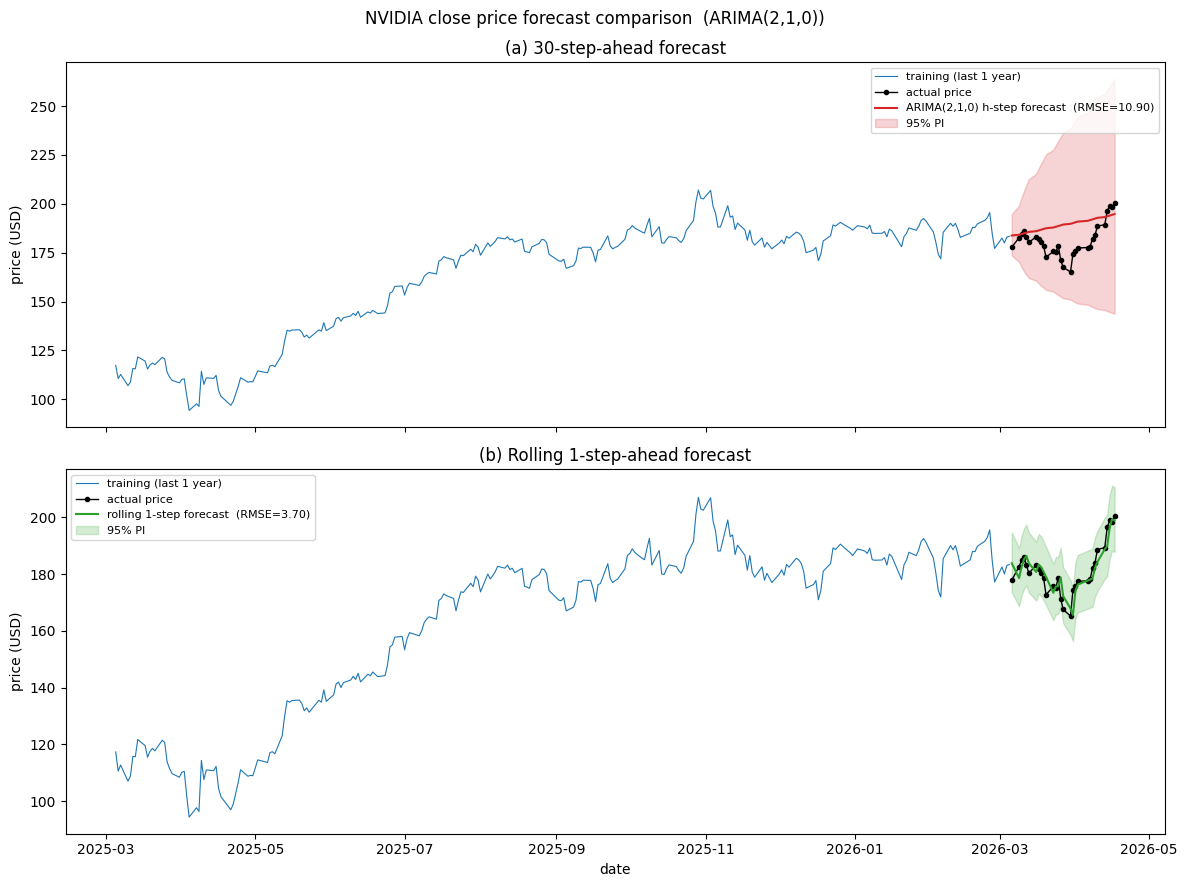

In [103]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

prior = close.iloc[-H - 252:-H]

# Top panel — h-step forecast
axes[0].plot(prior.index, prior.values, lw=0.8, color="C0", label="training (last 1 year)")
axes[0].plot(log_close_test.index, actual_price, lw=1.0, color="k",
             marker="o", markersize=3, label="actual price")
axes[0].plot(log_close_test.index, fc_price, lw=1.5, color="C3",
             label=f"ARIMA(2,1,0) h-step forecast  (RMSE={rmse:.2f})")
axes[0].fill_between(log_close_test.index, fc_price_lower, fc_price_upper,
                     color="C3", alpha=0.2, label="95% PI")
axes[0].set_title("(a) 30-step-ahead forecast")
axes[0].set_ylabel("price (USD)")
axes[0].legend(fontsize=8)

# Bottom panel — rolling 1-step forecast
axes[1].plot(prior.index, prior.values, lw=0.8, color="C0", label="training (last 1 year)")
axes[1].plot(log_close_test.index, actual_price, lw=1.0, color="k",
             marker="o", markersize=3, label="actual price")
axes[1].plot(log_close_test.index, rolling_preds, lw=1.5, color="C2",
             label=f"rolling 1-step forecast  (RMSE={rmse_roll:.2f})")
axes[1].fill_between(log_close_test.index, rolling_lower, rolling_upper,
                     color="C2", alpha=0.2, label="95% PI")
axes[1].set_title("(b) Rolling 1-step-ahead forecast")
axes[1].set_ylabel("price (USD)")
axes[1].set_xlabel("date")
axes[1].legend(fontsize=8)

fig.suptitle("NVIDIA close price forecast comparison  (ARIMA(2,1,0))", fontsize=12)
fig.tight_layout()
plt.show()
